# Data Exploration

Exploration of the two datasets we use in our assignment Fashion-MNIST and CIFAR-10 datasets.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sys

sys.path.append('..')

from src.data_loader import (
    download_fashion_mnist,
    download_cifar10,
    load_fashion_mnist, 
    load_cifar10, 
    get_class_names,
    preprocess_data
)

%matplotlib inline


In [2]:
# Reload modules if needed
import importlib
if 'src.data_loader' in sys.modules:
    importlib.reload(sys.modules['src.data_loader'])


1. Load Fashion-MNIST Dataset


In [3]:
data_dir = '../data'

download_fashion_mnist(data_dir)
X_train_fmnist, y_train_fmnist, X_test_fmnist, y_test_fmnist = load_fashion_mnist(data_dir)
fmnist_classes = get_class_names('fashion_mnist')

print(f"Training: {X_train_fmnist.shape[0]:,} images, Test: {X_test_fmnist.shape[0]:,} images")
print(f"Image size: {X_train_fmnist.shape[1]}x{X_train_fmnist.shape[2]}")


train-images-idx3-ubyte.gz already exists, skipping...
train-labels-idx1-ubyte.gz already exists, skipping...
t10k-images-idx3-ubyte.gz already exists, skipping...
t10k-labels-idx1-ubyte.gz already exists, skipping...
Training: 60,000 images, Test: 10,000 images
Image size: 28x28


2. Dataset Properties


In [4]:
print(f"Shapes: Train {X_train_fmnist.shape}, Test {X_test_fmnist.shape}")
print(f"Pixel range: {X_train_fmnist.min()}-{X_train_fmnist.max()}, dtype: {X_train_fmnist.dtype}")
print(f"Memory: {(X_train_fmnist.nbytes + X_test_fmnist.nbytes) / (1024**2):.1f} MB")


Shapes: Train (60000, 28, 28), Test (10000, 28, 28)
Pixel range: 0-255, dtype: uint8
Memory: 52.3 MB


3. Sample Images


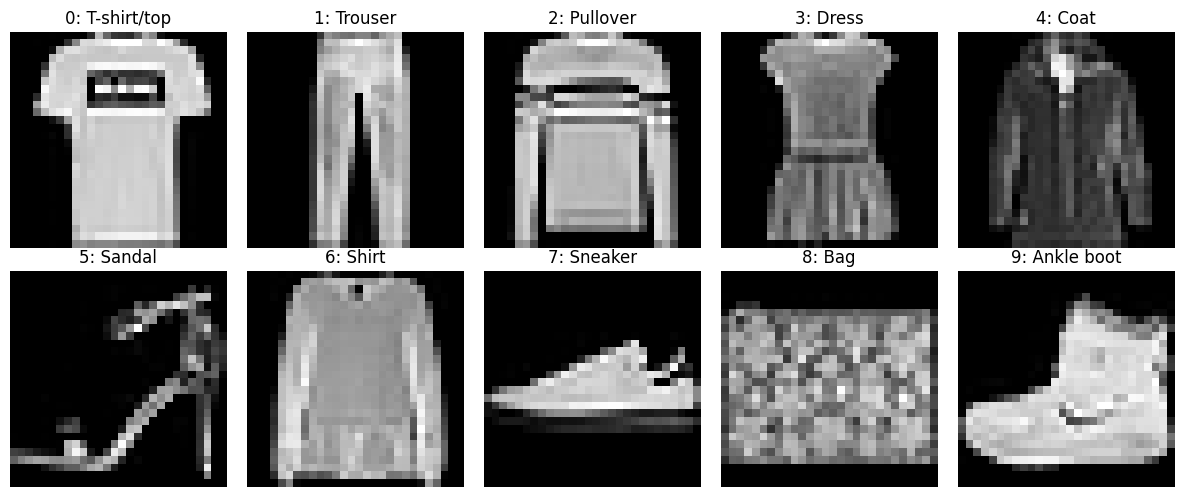

In [5]:
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    idx = np.where(y_train_fmnist == i)[0][0]
    ax.imshow(X_train_fmnist[idx], cmap='gray')
    ax.set_title(f'{i}: {fmnist_classes[i]}')
    ax.axis('off')
plt.tight_layout()
plt.show()


4. Class Distribution


In [6]:
train_counts = np.bincount(y_train_fmnist)
test_counts = np.bincount(y_test_fmnist)
print(f"Train: {train_counts.min()}-{train_counts.max()} per class (std: {train_counts.std():.1f})")
print(f"Test: {test_counts.min()}-{test_counts.max()} per class (std: {test_counts.std():.1f})")


Train: 6000-6000 per class (std: 0.0)
Test: 1000-1000 per class (std: 0.0)


5. Pixel Intensity Distribution


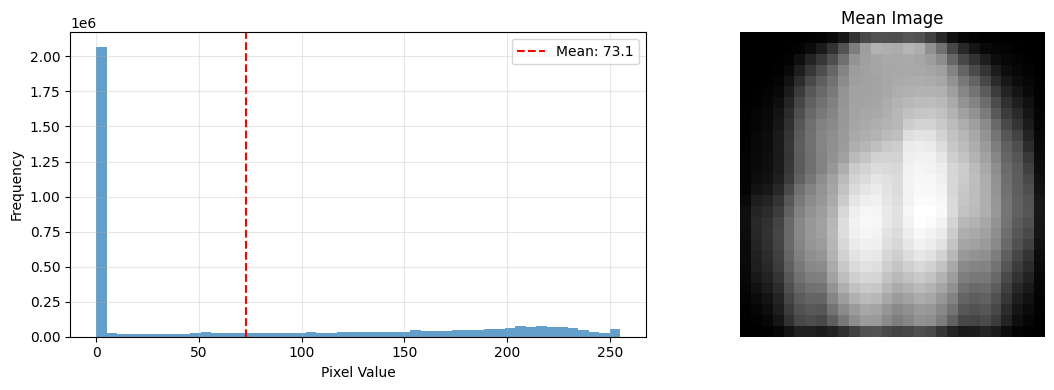

Mean: 73.1, Std: 90.3, Range: [0, 255]


In [7]:
sample_size = 5000
sample_idx = np.random.choice(len(X_train_fmnist), sample_size, replace=False)
pixels_flat = X_train_fmnist[sample_idx].flatten()
mean_image = X_train_fmnist.mean(axis=0)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(pixels_flat, bins=50, alpha=0.7)
axes[0].axvline(pixels_flat.mean(), color='r', linestyle='--', label=f'Mean: {pixels_flat.mean():.1f}')
axes[0].set_xlabel('Pixel Value')
axes[0].set_ylabel('Frequency')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].imshow(mean_image, cmap='gray')
axes[1].set_title('Mean Image')
axes[1].axis('off')
plt.tight_layout()
plt.show()

print(f"Mean: {pixels_flat.mean():.1f}, Std: {pixels_flat.std():.1f}, Range: [{pixels_flat.min()}, {pixels_flat.max()}]")


6. Load CIFAR-10


In [8]:
download_cifar10(data_dir)
X_train_cifar, y_train_cifar, X_test_cifar, y_test_cifar = load_cifar10(data_dir)
cifar_classes = get_class_names('cifar10')

print(f"Training: {X_train_cifar.shape[0]:,} images, Test: {X_test_cifar.shape[0]:,} images")
print(f"Image size: {X_train_cifar.shape[1]}x{X_train_cifar.shape[2]}x{X_train_cifar.shape[3]}")
print(f"Pixel range: {X_train_cifar.min()}-{X_train_cifar.max()}, dtype: {X_train_cifar.dtype}")


CIFAR-10 already downloaded and extracted
Training: 50,000 images, Test: 10,000 images
Image size: 32x32x3
Pixel range: 0-255, dtype: uint8


7. CIFAR-10 Samples


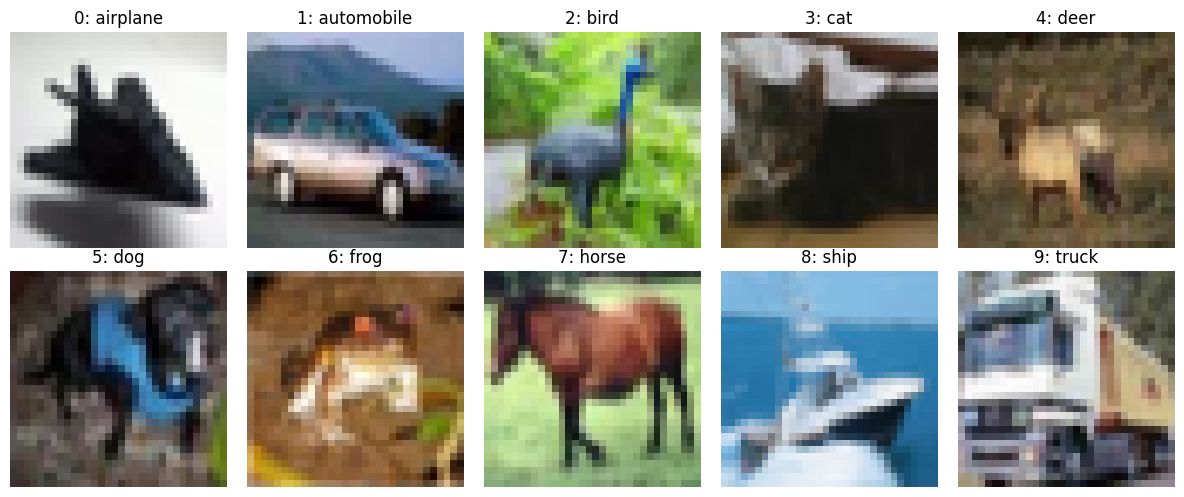

In [9]:
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    idx = np.where(y_train_cifar == i)[0][0]
    ax.imshow(X_train_cifar[idx])
    ax.set_title(f'{i}: {cifar_classes[i]}')
    ax.axis('off')
plt.tight_layout()
plt.show()


8. Dataset Comparison


In [10]:
import pandas as pd

comparison = pd.DataFrame({
    'Property': ['Training', 'Test', 'Image Size', 'Channels', 'Pixels', 'Memory'],
    'Fashion-MNIST': [
        f'{X_train_fmnist.shape[0]:,}',
        f'{X_test_fmnist.shape[0]:,}',
        '28x28',
        '1',
        '784',
        f'{X_train_fmnist.nbytes / (1024**2):.1f} MB'
    ],
    'CIFAR-10': [
        f'{X_train_cifar.shape[0]:,}',
        f'{X_test_cifar.shape[0]:,}',
        '32x32',
        '3',
        '3072',
        f'{X_train_cifar.nbytes / (1024**2):.1f} MB'
    ]
})

print(comparison.to_string(index=False))


  Property Fashion-MNIST CIFAR-10
  Training        60,000   50,000
      Test        10,000   10,000
Image Size         28x28    32x32
  Channels             1        3
    Pixels           784     3072
    Memory       44.9 MB 146.5 MB


9. Preprocessing Example


Before: shape (10, 28, 28), dtype uint8, range [0, 255]
After: shape (10, 784), dtype float32, range [0.000, 1.000]
Labels: 9 -> [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]


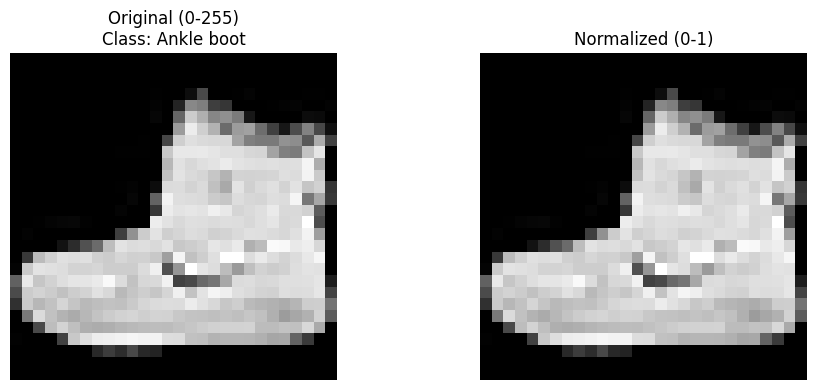

In [11]:
X_sample = X_train_fmnist[:10]
y_sample = y_train_fmnist[:10]

print(f"Before: shape {X_sample.shape}, dtype {X_sample.dtype}, range [{X_sample.min()}, {X_sample.max()}]")

X_processed, y_processed = preprocess_data(
    X_sample, y_sample, num_classes=10, flatten=True, normalize=True
)

print(f"After: shape {X_processed.shape}, dtype {X_processed.dtype}, range [{X_processed.min():.3f}, {X_processed.max():.3f}]")
print(f"Labels: {y_sample[0]} -> {y_processed[0]}")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(X_sample[0], cmap='gray')
axes[0].set_title(f'Original (0-255)\nClass: {fmnist_classes[y_sample[0]]}')
axes[0].axis('off')

axes[1].imshow(X_processed[0].reshape(28, 28), cmap='gray')
axes[1].set_title('Normalized (0-1)')
axes[1].axis('off')
plt.tight_layout()
plt.show()
